# An End-to-End AI Harvest Planner for Low-Cost Fruit-Picking Robots Built on a Physics-Consistent World Model

**`08_dataset_figures.ipynb`**

Figures for the report, from the dataset and the canopy.

This is not exploratory work — that happened while the dataset was being built. What this
notebook produces is the small set of pictures a reader needs to believe the rest: what the
detections look like, what the simulator turned them into, how the outcomes are distributed, and
where the fruit go between "on the tree" and "in the crate".

Everything is written to `runs/report/` as PNG alongside the figures `05_test` already produces.
Each figure is captioned here with the sentence it is meant to support in the report, so a
figure that supports nothing does not get made.


In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Default to the folder this notebook sits in, so a clone runs without setup. An absolute
# default only ever pointed at one machine, and an environment variable set in a shell does
# not reach a kernel that was already running.
ROOT = Path(os.environ.get("AIPICK_ROOT") or Path.cwd())
os.environ["AIPICK_ROOT"] = str(ROOT)
SRC, DATA, MODELS, RUNS = ROOT/"src", ROOT/"data", ROOT/"models", ROOT/"runs"
REPORT = RUNS/"report"; REPORT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(SRC))

import environment as E
E.load(ROOT, trees="trees_measured_pose.csv", dynamics=True)

GREEN, AMBER, RED, BLUE, GREY = "#2f6f4e", "#e8a33d", "#c0392b", "#31708e", "#c9c9c9"
# Legends sit under the plot rather than under the title: two-line titles and a
# horizontal legend at y=1.02 collide, and the collision is worse in the PNG than
# on screen.
PAPER = dict(template="plotly_white", margin=dict(l=90, r=45, t=110, b=120),
             font=dict(size=14))
pd.set_option("display.width", 200)


def save(fig, name, scale=2, show=True):
    """Write the figure, then display it in the notebook.

    The displayed copy is a static PNG rather than the interactive widget: it survives being
    saved into the .ipynb, so the figure travels with the notebook and can be looked at without
    opening the report folder.
    """
    fig.write_html(REPORT/f"{name}.html", include_plotlyjs="cdn")
    out = f"{name}.html only -- kaleido missing"
    try:
        fig.write_image(REPORT/f"{name}.png", scale=scale)
        out = f"{name}.png + .html"
    except Exception as ex:
        out = f"{name}.html only -- {type(ex).__name__}; pip install -U kaleido"
    if show:
        try:
            from IPython.display import Image, display
            display(Image(filename=str(REPORT/f"{name}.png")))
        except Exception:
            fig.show()
    return out


D = pd.read_csv(DATA/"picks.csv")
D["apple_id"] = D.apple_id.astype(str)
bad = set(D.loc[(D.seat_x_palm > 2.0) | D.seat_x_palm.isna() |
                (D.secs > 30) | (D.n_fingers > 3), "apple_id"])
D = D[~D.apple_id.isin(bad)]
DAMAGE = ("STEM_PULL", "STALK_SNAP", "SPUR_BREAK")
D["y"] = D.code.map(lambda c: "DEFECT" if c in DAMAGE else c)

print(f"picks.csv   {len(D):,} rows / {D.apple_id.nunique():,} fruit "
      f"({len(bad):,} fruit dropped as divergent)")
print(f"canopy      {len(E.T):,} fruit / {E.T.tree.nunique()} trees")
print(f"figures ->  {REPORT}")






picks.csv   31,960 rows / 7,990 fruit (143 fruit dropped as divergent)
canopy      6,000 fruit / 50 trees
figures ->  c:\aipick\git\runs\report


## 0. From a detection to a physics scene to a canopy

Before any chart, the reader needs to see the three things this project turns into one another:
**what the orchard data actually is**, **what the simulator makes of one fruit**, and **what a
synthetic tree looks like**. The rest of the report describes transformations between them, and
those are hard to follow without having seen the ends.

This section writes four images. It first takes an inventory of what is on disk, because the
source data may be point clouds, image crops, or both, and the figure adapts to what is there.


In [2]:
CROPS = ROOT/"apple_crops"
print(f"{CROPS}\n")
if not CROPS.exists():
    print("  not present -- the FRESH source is not in this tree")
else:
    for sub in sorted(p for p in CROPS.iterdir() if p.is_dir()):
        files = list(sub.iterdir())
        ext = {}
        for f in files[:400]:
            ext[f.suffix.lower()] = ext.get(f.suffix.lower(), 0) + 1
        print(f"  {sub.name+'/':<14} {len(files):>6,} files   {ext}")
        if files:
            print(f"      e.g. {files[0].name}")
    loose = [p for p in CROPS.iterdir() if p.is_file()]
    for f in loose:
        print(f"  {f.name:<24} {f.stat().st_size/1024:8.1f} KB")

# what a point cloud looks like, if that is what is there
PC = CROPS/"pc"
if PC.exists():
    import numpy as _np
    f0 = sorted(PC.glob("*.npy"))[:1]
    if f0:
        a = _np.load(f0[0])
        print(f"\n  point cloud {f0[0].name}: shape {a.shape}, dtype {a.dtype}")
        print(f"  ranges: {_np.round(a.min(0), 3)} to {_np.round(a.max(0), 3)}")



c:\aipick\git\apple_crops

  depth/             24 files   {'.npy': 24}
      e.g. 000000_475_0.npy
  pc/             8,135 files   {'.npy': 400}
      e.g. 000000_475_0.npy
  rgb/            8,135 files   {'.png': 400}
      e.g. 000000_475_0.png
  .gitkeep                      0.0 KB
  manifest.csv               1428.9 KB
  manifest.preZfix.csv       1358.8 KB
  pc_stats.json                 0.5 KB

  point cloud 000000_475_0.npy: shape (3710, 6), dtype float32
  ranges: [ 0.247 -0.081 -2.873  0.204  0.153  0.016] to [ 0.308 -0.055 -2.734  0.573  0.537  0.388]


### 0.1 What a detection looks like, and how many fruit touch

The FRESH crops are the ground this project stands on. Four of them are shown here, chosen to
span the cluster sizes that occur: a fruit on its own, two touching, three, and four. **Four is
already rare** — that is why the simulator stages a target with up to two or three neighbours and
not more, and why the dynamics model is asked about a handful of survivors rather than a crowd.

Read them alongside the simulator panels that follow. The crop is what the camera saw; the panel
is what the physics was asked to reproduce from it.


  fig0_crops.png     4 crops


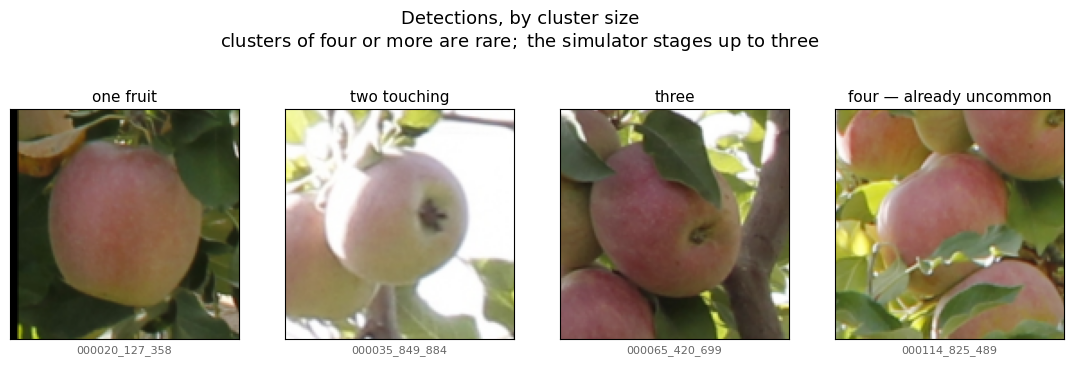


  fruit by how many others sit within 90 mm (synthetic canopy)

    cluster of 1    65.3%
    cluster of 2    30.1%
    cluster of 3     4.4%
    cluster of 4     0.2%


In [3]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from IPython.display import display

# The crops live with the source data, which is not inside `final` -- it is not redistributed,
# so the path is the working copy and this cell degrades to a note if it is absent.
RGB = Path(os.environ.get("AIPICK_CROPS", r"C:\aipick\apple_crops"))/"rgb"

SAMPLES = [("000020_127_358", "one fruit"),
           ("000035_849_884", "two touching"),
           ("000065_420_699", "three"),
           ("000114_825_489", "four — already uncommon")]

found = [(RGB/f"{sid}.png", cap) for sid, cap in SAMPLES if (RGB/f"{sid}.png").exists()]
if not found:
    print(f"crops not found under {RGB}")
    print("  set AIPICK_CROPS if the working copy is elsewhere; this panel is skipped")
else:
    fig, axes = plt.subplots(1, len(found), figsize=(3.4*len(found), 3.8))
    axes = np.atleast_1d(axes)
    for ax, (p, cap) in zip(axes, found):
        ax.imshow(plt.imread(p))
        ax.set_title(cap, fontsize=11)
        ax.set_xlabel(p.stem, fontsize=8, color="#666")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.suptitle("Detections, by cluster size"
                 "\n$\\mathregular{clusters\\ of\\ four\\ or\\ more\\ are\\ rare;\\ the\\ "
                 "simulator\\ stages\\ up\\ to\\ three}$", y=1.06, fontsize=13)
    fig.savefig(REPORT/"fig0_crops.png", dpi=200, bbox_inches="tight")
    print(f"  fig0_crops.png     {len(found)} crops")
    display(fig)
    plt.close(fig)

    # how often each cluster size actually occurs, so the caption is not an impression
    if "vis_any" in E.T:
        V = E.T[E.T.vis_any]
        sizes = []
        for tid, g in V.groupby("tree"):
            P = g[["x", "y", "z"]].to_numpy(float)
            d = np.linalg.norm(P[:, None] - P[None], axis=2)
            near = (d < 0.09) & (d > 1e-9)
            sizes.extend(near.sum(1) + 1)
        s = pd.Series(sizes).value_counts(normalize=True).sort_index()*100
        print("\n  fruit by how many others sit within 90 mm (synthetic canopy)\n")
        for k, v in s.items():
            if v >= 0.05:
                print(f"    cluster of {k:<3} {v:5.1f}%")



tree 23, fruit 22: 2 neighbour(s) within 90 mm, diameter 52 mm, stalk tilt 64 deg
  fig0a_source.png   point cloud, 3,710 points
  fig0b_single.png   fruit + 5-segment stalk + spur + gripper
  fig0c_cluster.png  the same fruit with 2 neighbour(s)
  fig0d_tree.png     synthetic canopy, 97 fruit

  fig0_story.png     contact sheet, 4 panels


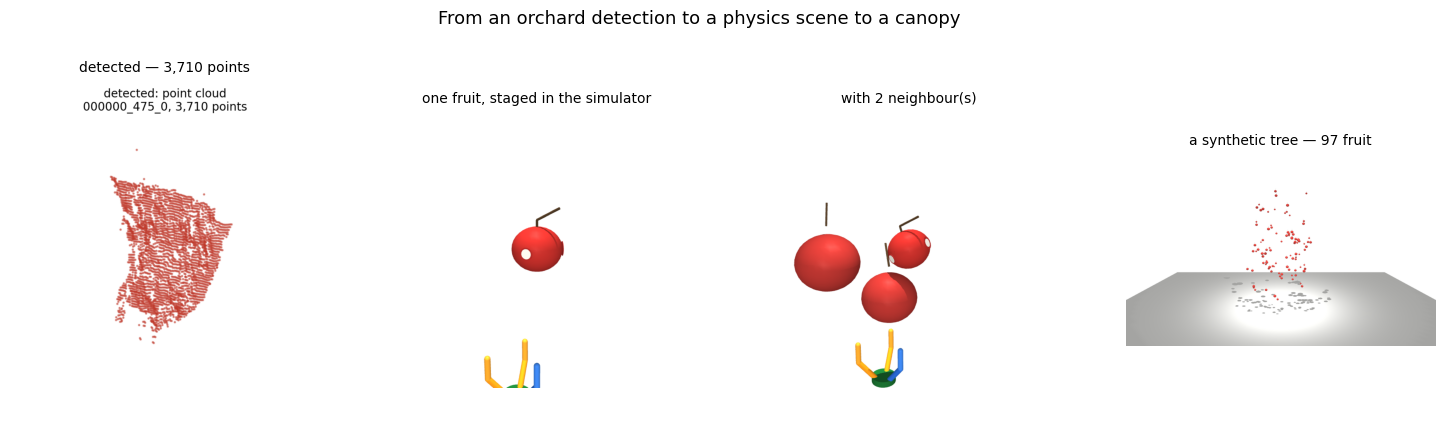

In [4]:
import mujoco, importlib.util
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

spec = importlib.util.spec_from_file_location("gen", SRC/"generate.py")
G = importlib.util.module_from_spec(spec); G.__name__ = "gen"
spec.loader.exec_module(G)
import physics as A

# A fruit with neighbours, so the cluster panel has something to show.
T = E.T
cand = T[(T.tree == 23) & T.vis_any]
best, best_n = None, -1
for _, r in cand.iterrows():
    d = np.linalg.norm(cand[["x", "y", "z"]].to_numpy(float)
                       - np.array([r.x, r.y, r.z]), axis=1)
    n = int(((d > 1e-9) & (d < 0.09)).sum())
    if n > best_n:
        best, best_n = r, n
print(f"tree 23, fruit {int(best.fruit_id)}: {best_n} neighbour(s) within 90 mm, "
      f"diameter {best.dim*1000:.0f} mm, stalk tilt "
      f"{np.degrees(np.arccos(abs(best.sdir_y))):.0f} deg")

R_T2S = np.array([[1.0, 0, 0], [0, 0, 1], [0, 1, 0]])


def units_around(row, k):
    """The target fruit and its k nearest neighbours, in the scene frame."""
    sub = T[(T.tree == row.tree) & (T.fruit_id != row.fruit_id)]
    c0 = np.array([row.x, row.y, row.z], float)
    d = np.linalg.norm(sub[["x", "y", "z"]].to_numpy(float) - c0, axis=1)
    near = sub.iloc[np.argsort(d)[:k]]
    out = [dict(name="A", abs_pt=np.zeros(3),
                sdir=R_T2S @ np.array([row.sdir_x, row.sdir_y, row.sdir_z], float),
                dim=float(row.dim), apple_id=int(row.fruit_id))]
    for i, (_, o) in enumerate(near.iterrows()):
        out.append(dict(name=f"N{i}", abs_pt=R_T2S @ (np.array([o.x, o.y, o.z], float) - c0),
                        sdir=R_T2S @ np.array([o.sdir_x, o.sdir_y, o.sdir_z], float),
                        dim=float(o.dim), apple_id=int(o.fruit_id)))
    return out


def render(units, dim_true, cam=(0.34, 135.0, -12.0), w=760, h=680):
    m = mujoco.MjModel.from_xml_string(
        G.scene_for(units, G.aperture_from(1.0, dim_true), dim_true=dim_true))
    d = mujoco.MjData(m)
    G.settle_scene(m, d)
    mujoco.mj_forward(m, d)
    r = mujoco.Renderer(m, height=h, width=w)
    c = mujoco.MjvCamera(); mujoco.mjv_defaultCamera(c)
    c.distance, c.azimuth, c.elevation = cam
    c.lookat[:] = d.body("fruit").xpos
    r.update_scene(d, camera=c)
    return r.render()


panels = []

# (1) the source data, whatever form it takes
PC = ROOT/"apple_crops"/"pc"
if PC.exists() and any(PC.glob("*.npy")):
    f = PC/f"{int(best.fruit_id):06d}.npy"
    f = f if f.exists() else sorted(PC.glob("*.npy"))[0]
    pts = np.load(f)
    fig0 = plt.figure(figsize=(5.2, 4.6))
    ax = fig0.add_subplot(111, projection="3d")
    step = max(1, len(pts)//4000)
    ax.scatter(pts[::step, 0], pts[::step, 2], pts[::step, 1], s=1.2,
               c="#c0392b", alpha=0.5)
    ax.set_box_aspect([1, 1, 1]); ax.set_axis_off()
    ax.set_title(f"detected: point cloud\n{f.stem}, {len(pts):,} points", fontsize=10)
    fig0.savefig(REPORT/"fig0a_source.png", dpi=200, bbox_inches="tight")
    plt.close(fig0)
    panels.append(("fig0a_source.png", f"detected — {len(pts):,} points"))
    print(f"  fig0a_source.png   point cloud, {len(pts):,} points")
else:
    print("  no point clouds found; the source panel is skipped")

# (2) one fruit, as the simulator builds it
img1 = render(units_around(best, 0), float(best.dim))
plt.imsave(REPORT/"fig0b_single.png", img1)
panels.append(("fig0b_single.png", "one fruit, staged in the simulator"))
print("  fig0b_single.png   fruit + 5-segment stalk + spur + gripper")

# (3) the same fruit with its neighbours
img2 = render(units_around(best, min(2, best_n)), float(best.dim), cam=(0.40, 135.0, -12.0))
plt.imsave(REPORT/"fig0c_cluster.png", img2)
panels.append(("fig0c_cluster.png", f"with {min(2, best_n)} neighbour(s)"))
print(f"  fig0c_cluster.png  the same fruit with {min(2, best_n)} neighbour(s)")

# (4) a whole synthetic tree
try:
    import replay
    RP = replay.TreeReplay(T, tree=23, arm=(0.200, 0.600), settle=600)
    RP.still(REPORT/"fig0d_tree.png", azimuth=90, elevation=-8)
    panels.append(("fig0d_tree.png", f"a synthetic tree — {len(RP.units)} fruit"))
    print(f"  fig0d_tree.png     synthetic canopy, {len(RP.units)} fruit")
except Exception as ex:
    print(f"  tree render unavailable ({type(ex).__name__}: {ex})")

# a contact sheet so the four sit together in one file
if panels:
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(4.6*n, 4.4))
    axes = np.atleast_1d(axes)
    for ax, (name, cap) in zip(axes, panels):
        ax.imshow(plt.imread(REPORT/name))
        ax.set_title(cap, fontsize=10)
        ax.axis("off"); ax.grid(False)
    fig.suptitle("From an orchard detection to a physics scene to a canopy", y=1.04,
                 fontsize=13)
    fig.savefig(REPORT/"fig0_story.png", dpi=180, bbox_inches="tight")
    print(f"\n  fig0_story.png     contact sheet, {n} panels")
    from IPython.display import display
    display(fig)
    plt.close(fig)




### What these four show

```
fig0a  the source                what an orchard detection actually is
fig0b  one fruit, staged         fruit, five-segment stalk, spur, and a gripper sized to it
fig0c  the same fruit, clustered  what makes a pick a sequential decision
fig0d  a synthetic tree           the canopy the planning layer works on
fig0_story                        all four in one sheet
```

**`fig0b` is the one that carries the section.** It shows that the simulator does not place a
generic apple in a generic gripper — the gripper is sized from this fruit's diameter, the stalk
hangs at the direction the detection recorded, and the abscission zone is a free pivot, which is
why the fruit hangs plumb even when its stalk does not.

`fig0c` is the reason a harvest is a plan rather than a list. Take one and the other moves.


## 1. What the detections are, and what the simulator made of them

The dataset begins with real detections and ends with outcome labels that do not exist anywhere
in the public record. The first figure shows the two ends: the size and stalk-direction
distribution the detections carry, and the outcome distribution the simulator produced from them.

**Supports:** *"The dataset begins with 8,133 real detections and ends with 32,532 labelled
picks — four apertures per fruit, from the same settled scene."*


detections: 8,133 fruit, stalk tilt median 27.0 deg, diameter 69 mm mean



Resorting to unclean kill browser.


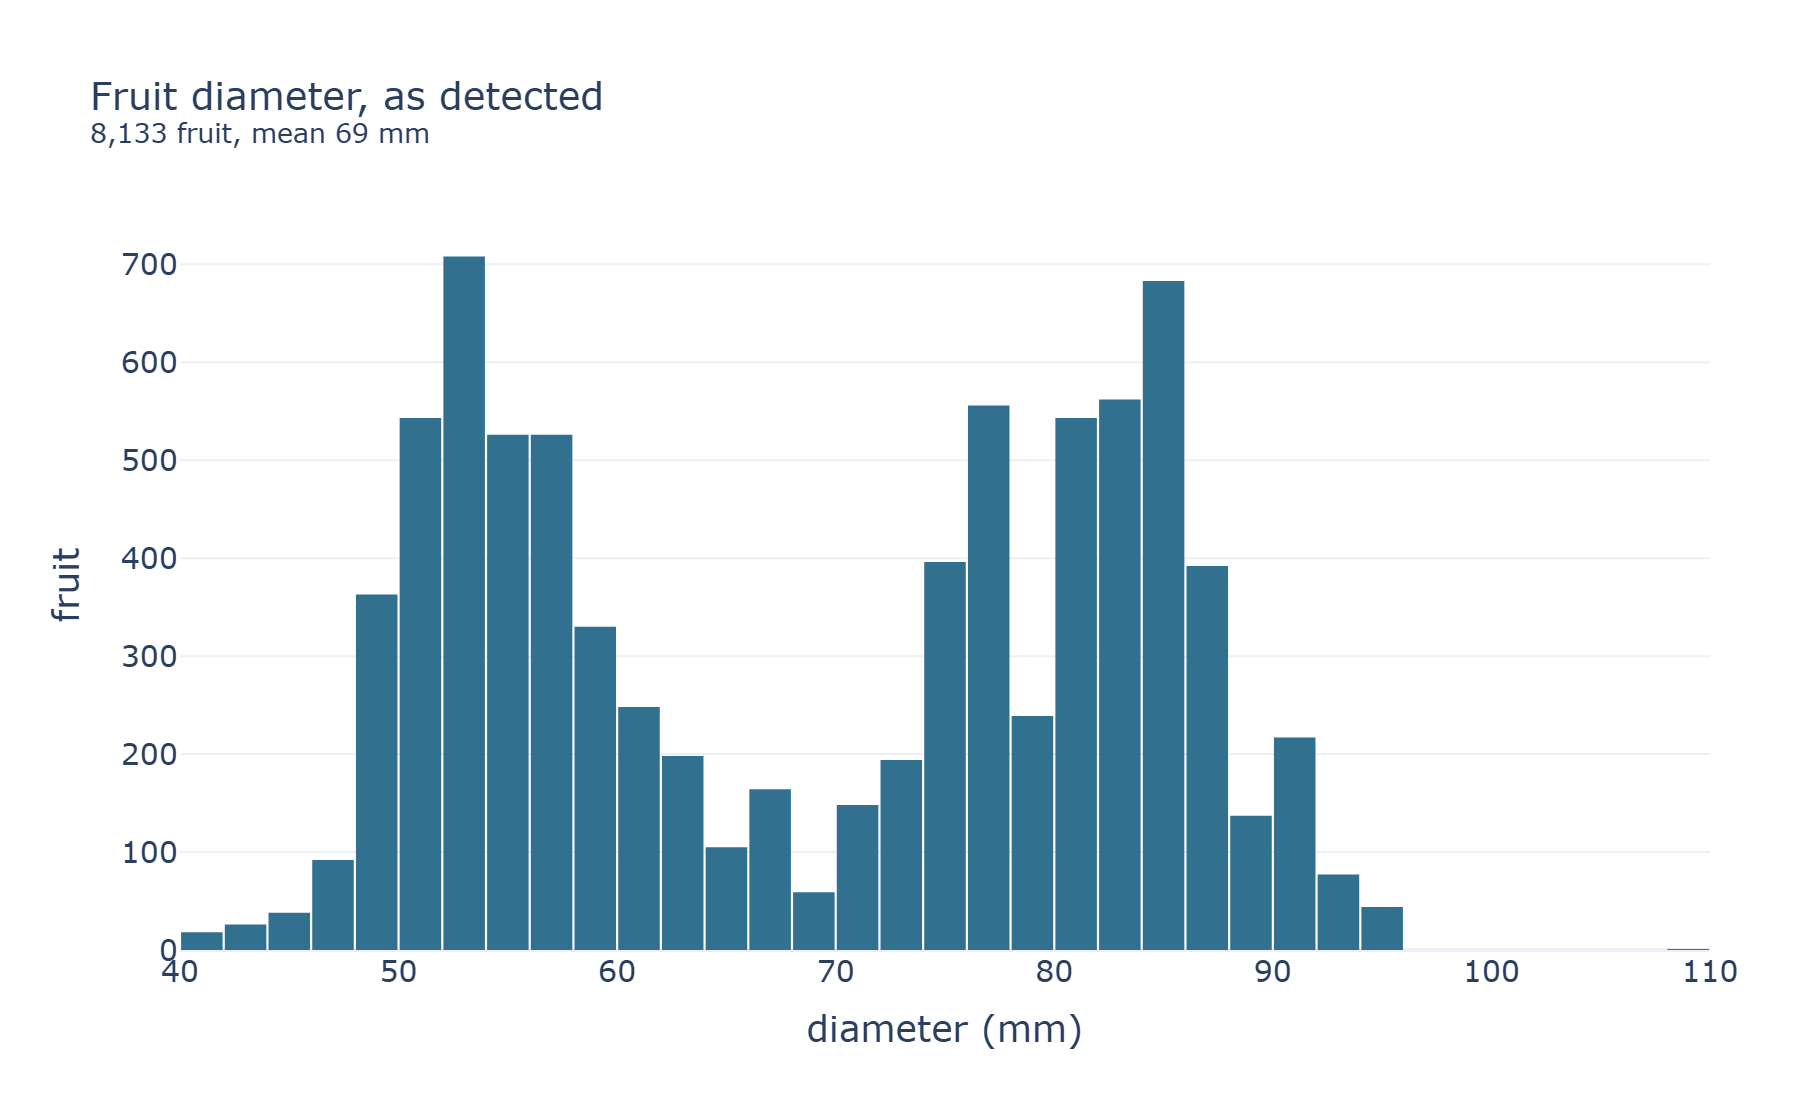

  fig8a_diameter.png + .html


Resorting to unclean kill browser.


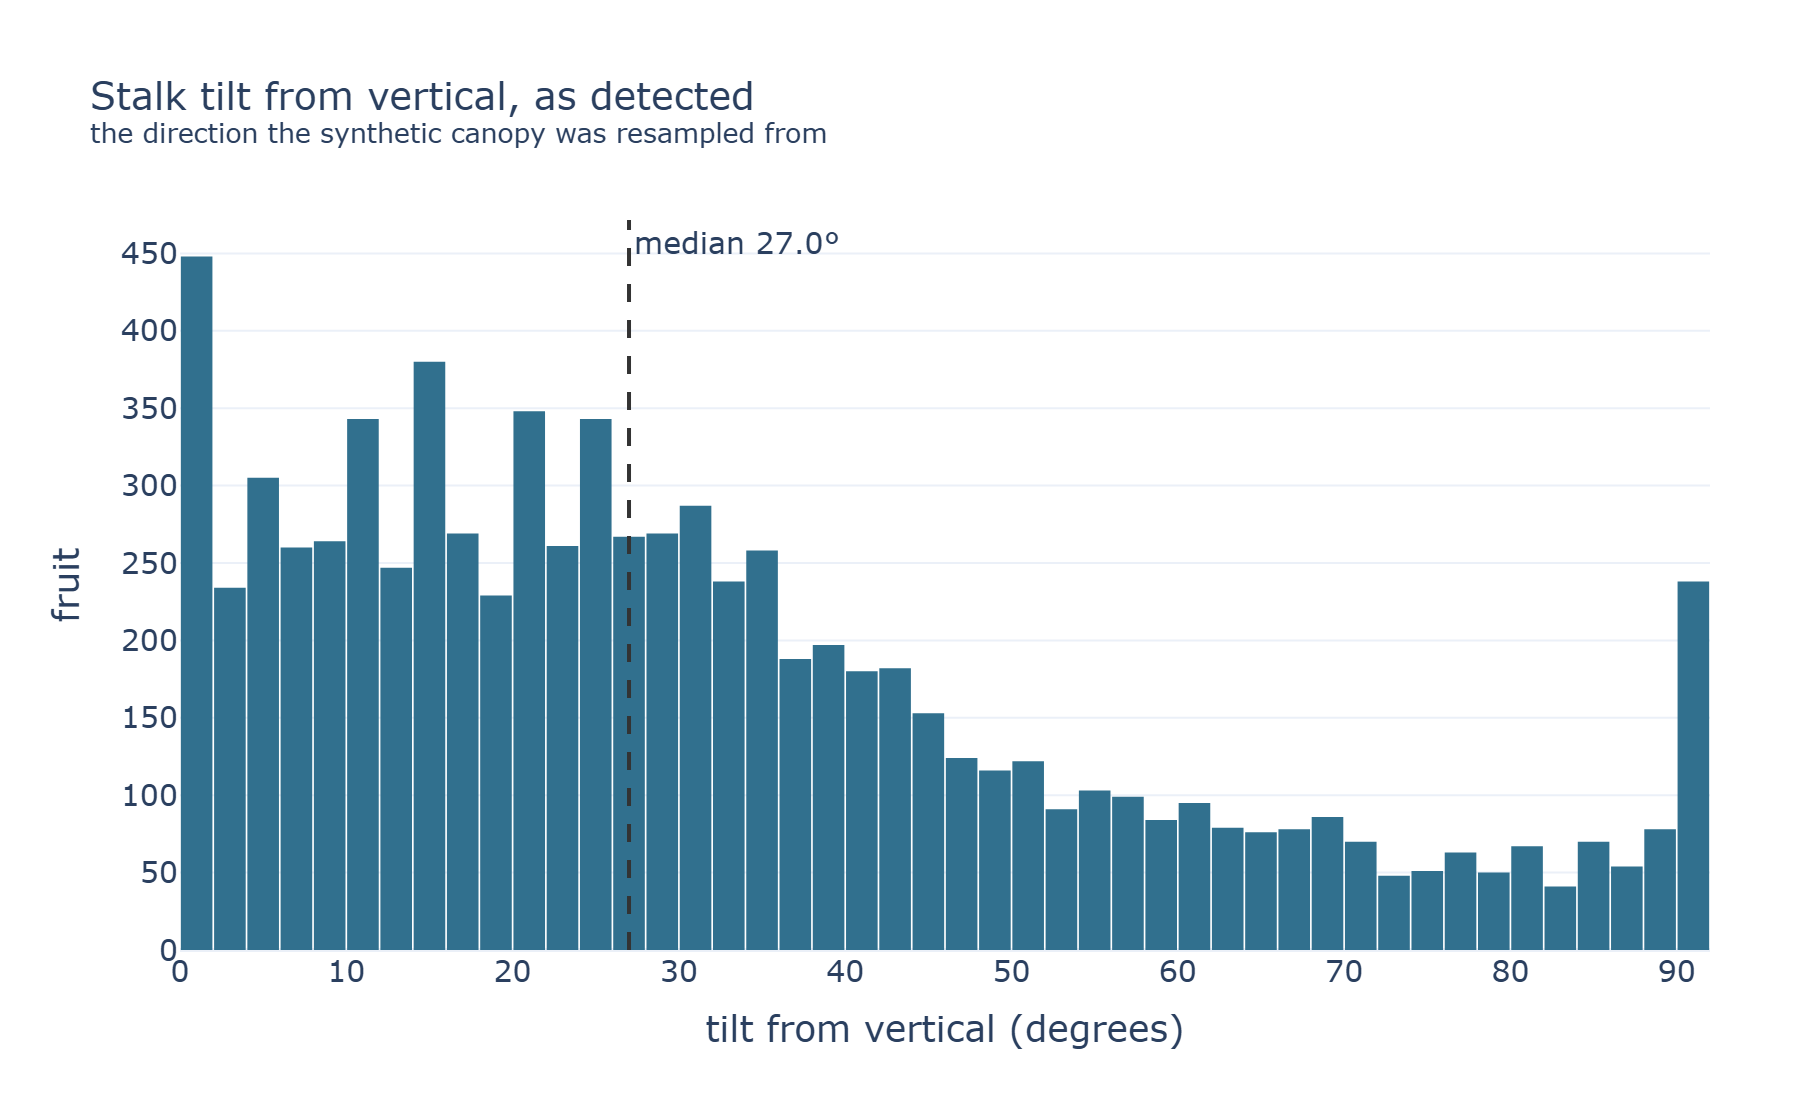

  fig8b_tilt.png + .html


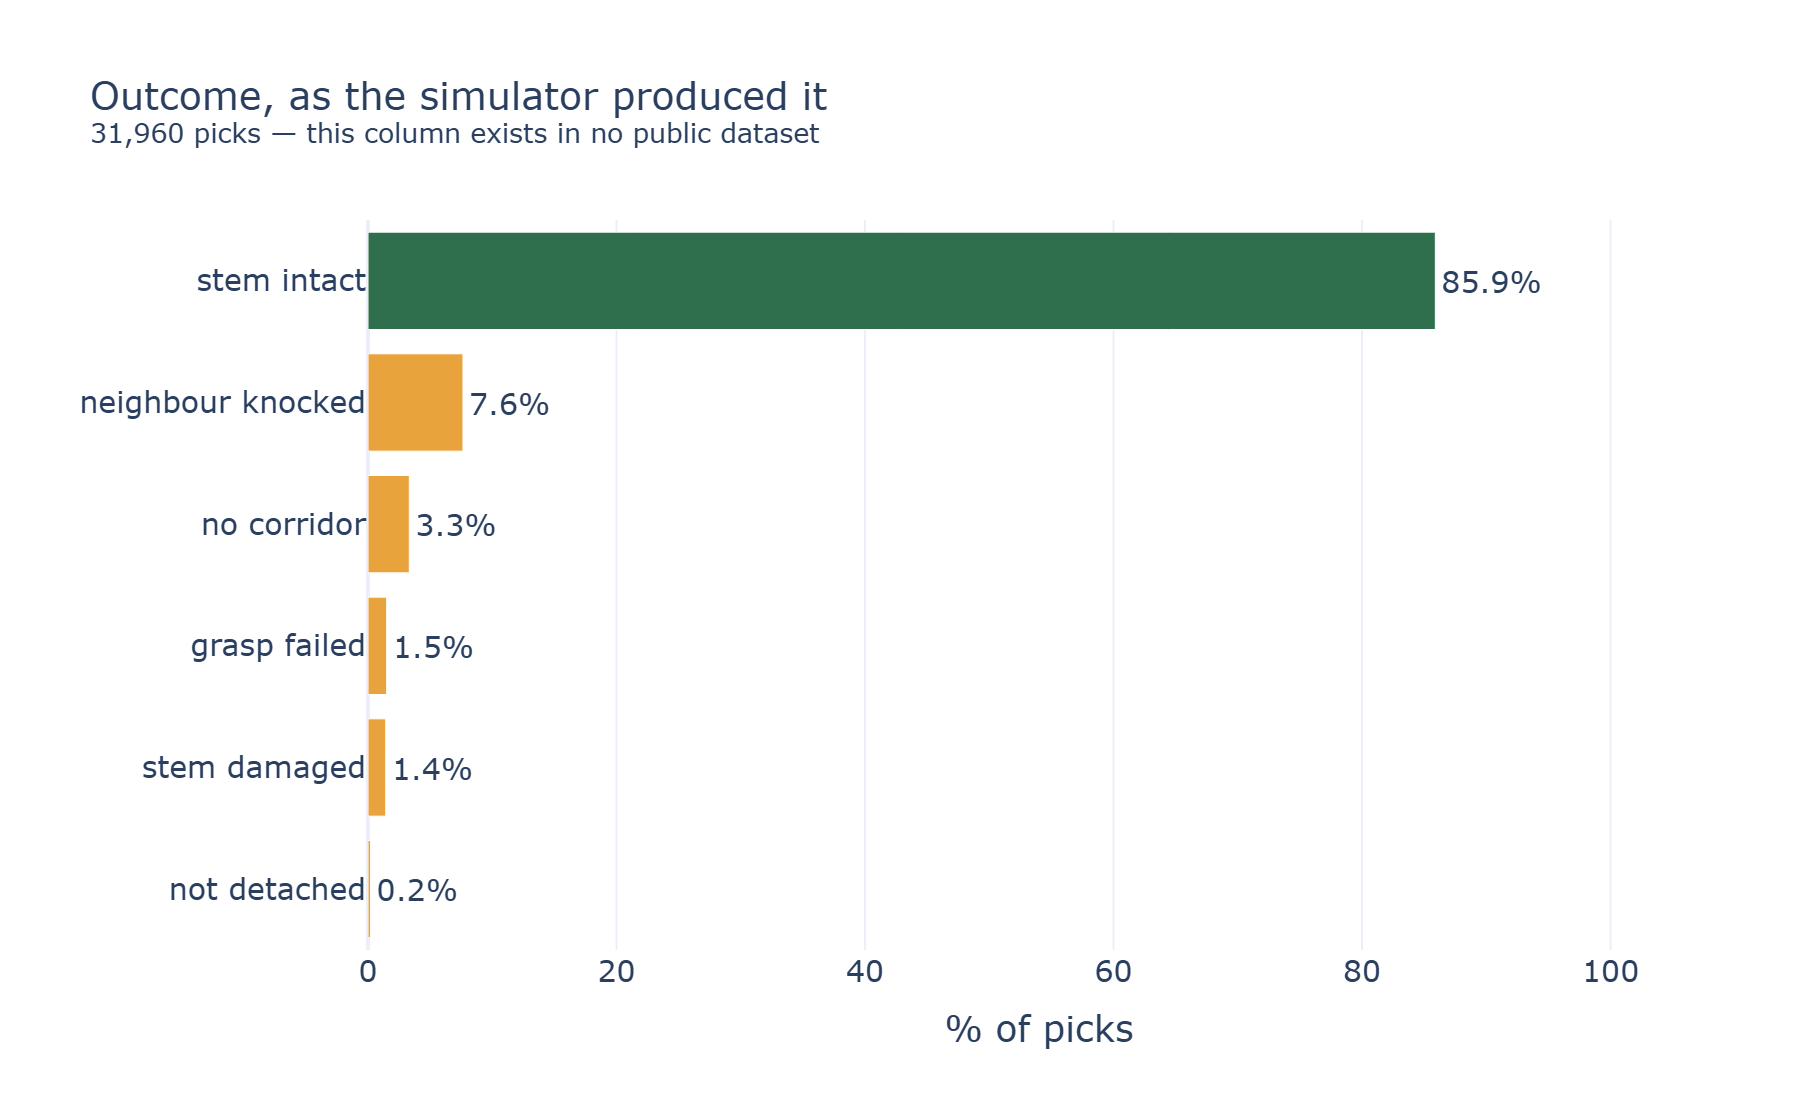

  fig8c_outcomes.png + .html


In [5]:
MAN = pd.read_csv(ROOT/"apple_crops"/"manifest.csv")

# FRESH stores stalk direction as `approach_*` -- the X axis of its oriented bounding box, which
# runs from the fruit centre to the calyx. The three components are already a unit vector, and y
# is the vertical axis: taking the tilt about y gives a median of 27.0 degrees, which is the
# figure the report quotes and the distribution the corrected canopy was resampled from.
A = MAN[["approach_x", "approach_y", "approach_z"]].to_numpy(float)
assert abs(np.linalg.norm(A, axis=1) - 1).max() < 1e-3, "approach_* is not a unit vector"
tilt_det = np.degrees(np.arccos(np.clip(np.abs(A[:, 1]), 0, 1)))
assert abs(np.median(tilt_det) - 27.0) < 0.5, (
    f"median tilt {np.median(tilt_det):.1f} deg -- the vertical axis is not y after all")
print(f"detections: {len(MAN):,} fruit, stalk tilt median {np.median(tilt_det):.1f} deg, "
      f"diameter {MAN.dim.mean()*1000:.0f} mm mean\n")

# Three separate figures rather than one row of three panels. Squeezed into a shared row the
# axis labels ran into each other and the shared title had to be cut to fit a page; each panel
# gets the full width in the report, so each is drawn at that width here.
#
# The title is passed per figure, so it is not in PANEL -- plotly rejects the same keyword
# arriving twice. `titlefont` was removed from the layout schema, so the size travels inside
# the title dict instead.
PANEL = dict(width=900, height=560, template="plotly_white",
             margin=dict(l=90, r=45, t=110, b=85), font=dict(size=15))


def title(text, sub=None):
    """A two-line title: the heading, then a smaller line under it."""
    t = text if sub is None else f"{text}<br><sup>{sub}</sup>"
    return dict(text=t, font=dict(size=19))


f8a = go.Figure(go.Histogram(x=MAN.dim*1000, marker_color=BLUE, nbinsx=40,
                             showlegend=False))
f8a.update_layout(
    title=title("Fruit diameter, as detected",
                f"{len(MAN):,} fruit, mean {MAN.dim.mean()*1000:.0f} mm"),
    xaxis_title="diameter (mm)", yaxis_title="fruit", bargap=0.05, **PANEL)
print(" ", save(f8a, "fig8a_diameter"))

f8b = go.Figure(go.Histogram(x=tilt_det, marker_color=BLUE, nbinsx=45, showlegend=False))
f8b.add_vline(x=float(np.median(tilt_det)), line=dict(dash="dash", color="#333"),
              annotation_text=f"median {np.median(tilt_det):.1f}°",
              annotation_position="top right")
f8b.update_layout(
    title=title("Stalk tilt from vertical, as detected",
                "the direction the synthetic canopy was resampled from"),
    xaxis_title="tilt from vertical (degrees)", yaxis_title="fruit", bargap=0.05, **PANEL)
print(" ", save(f8b, "fig8b_tilt"))

mix = (D.y.value_counts(normalize=True)*100).sort_values()
LABEL = {"SUCCESS": "stem intact", "NEIGHBOR_KNOCKED": "neighbour knocked",
         "DEFECT": "stem damaged", "GRASP_FAILED": "grasp failed",
         "APPROACH_BLOCKED": "no corridor", "NO_DETACH": "not detached"}
f8c = go.Figure(go.Bar(
    x=mix.values, y=[LABEL.get(i, i) for i in mix.index], orientation="h",
    showlegend=False,
    marker_color=[GREEN if i == "SUCCESS" else AMBER for i in mix.index],
    text=[f"{v:.1f}%" for v in mix.values], textposition="outside",
    cliponaxis=False))
f8c.update_layout(
    title=title("Outcome, as the simulator produced it",
                f"{len(D):,} picks — this column exists in no public dataset"),
    xaxis_title="% of picks", xaxis_range=[0, 108], yaxis_title="", **PANEL)
print(" ", save(f8c, "fig8c_outcomes"))

## 2. The counterfactual structure

Every fruit is evaluated at four gripper apertures **from the same settled scene**. That is what
separates the effect of opening the basket wider from the effect of the fruit being different,
and it is not something an observational dataset can offer.

**Supports:** *"A wider aperture helps, and the dataset can say so because the four rows for a
fruit differ only in aperture."*


            n  ratio  success  blocked  knocked
ap_rank                                        
1        7990   0.85   87.184    4.130    6.571
2        7990   1.00   87.084    1.952    7.760
3        7990   1.20   85.907    2.979    8.010
4        7990   1.45   83.404    4.230    8.235


Resorting to unclean kill browser.


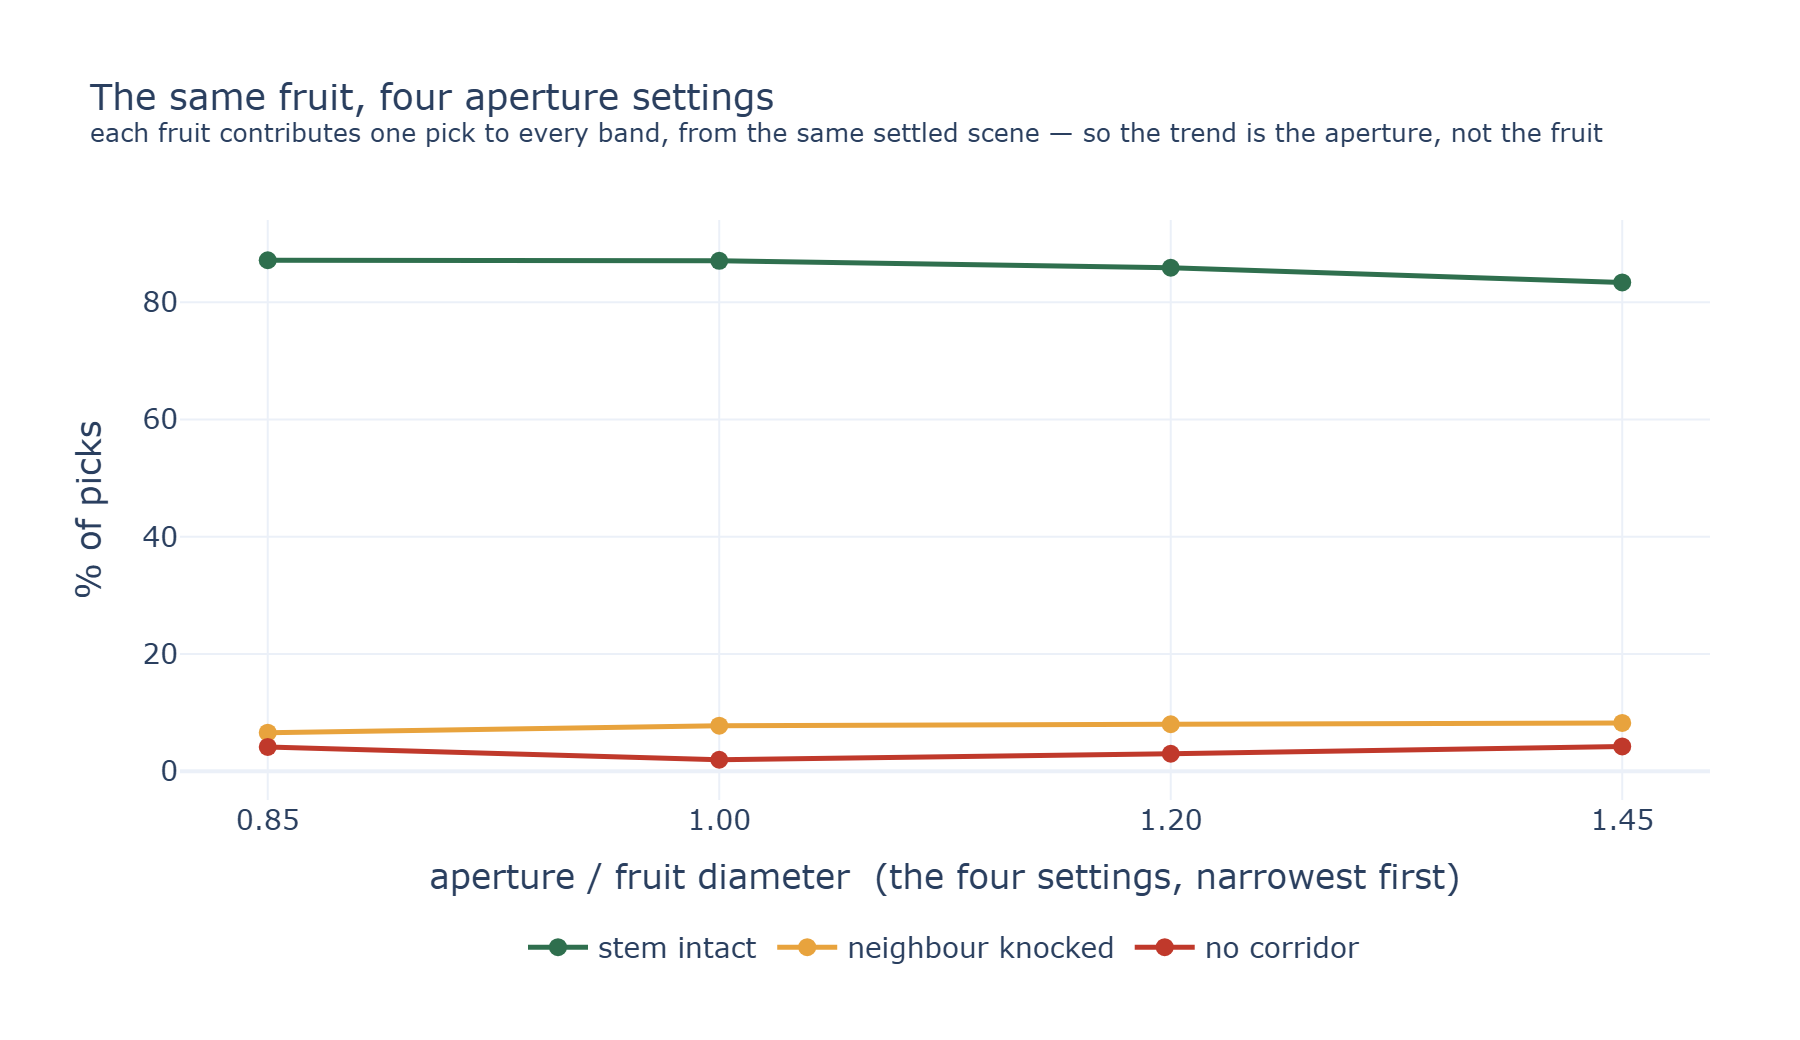

  fig9_aperture.png + .html


In [6]:
# The four apertures are a fixed set per fruit, not a continuum -- binning by ratio put two of
# them in one bucket and left another empty. Ranking within each fruit recovers the four groups
# the dataset actually has.
D["ap_rank"] = D.groupby("apple_id").aperture_ratio.rank(method="first").astype(int)
ap = (D.groupby("ap_rank")
        .agg(n=("y", "size"), ratio=("aperture_ratio", "mean"),
             success=("y", lambda s: (s == "SUCCESS").mean()*100),
             blocked=("y", lambda s: (s == "APPROACH_BLOCKED").mean()*100),
             knocked=("y", lambda s: (s == "NEIGHBOR_KNOCKED").mean()*100)))
print(ap.round(3).to_string())

fig = go.Figure()
x = [f"{r:.2f}" for r in ap.ratio]
for col, name, colour in (("success", "stem intact", GREEN),
                          ("knocked", "neighbour knocked", AMBER),
                          ("blocked", "no corridor", RED)):
    fig.add_trace(go.Scatter(x=x, y=ap[col], name=name, mode="lines+markers",
                             line=dict(color=colour, width=2.5), marker=dict(size=9)))

# PAPER carries a title font, so the title text is merged into that dict rather than passed
# as its own keyword — plotly rejects the same keyword arriving twice.
LAYOUT = {k: v for k, v in PAPER.items() if k != "title"}
fig.update_layout(
    title=dict(text="The same fruit, four aperture settings"
                    "<br><sup>each fruit contributes one pick to every band, from the same "
                    "settled scene — so the trend is the aperture, not the fruit</sup>",
               font=dict(size=18)),
    xaxis_title="aperture / fruit diameter  (the four settings, narrowest first)",
    yaxis_title="% of picks",
    legend=dict(orientation="h", yanchor="top", y=-0.20, xanchor="center", x=0.5),
    width=900, height=520, **LAYOUT)
print(" ", save(fig, "fig9_aperture"))

## 3. The canopy, and the defect that was found in it

Three generations of synthetic canopy exist because the difference between them is a result.
The first drew stalk directions from a uniform distribution and never read them from the
detections — a defect that raised no error and produced summary statistics that looked
reasonable.

**Supports:** *"The synthetic canopy drew stalk directions from a uniform distribution. Nothing
raised an error; the median tilt was 44.8 degrees against 27.0 in the detections."*


Resorting to unclean kill browser.


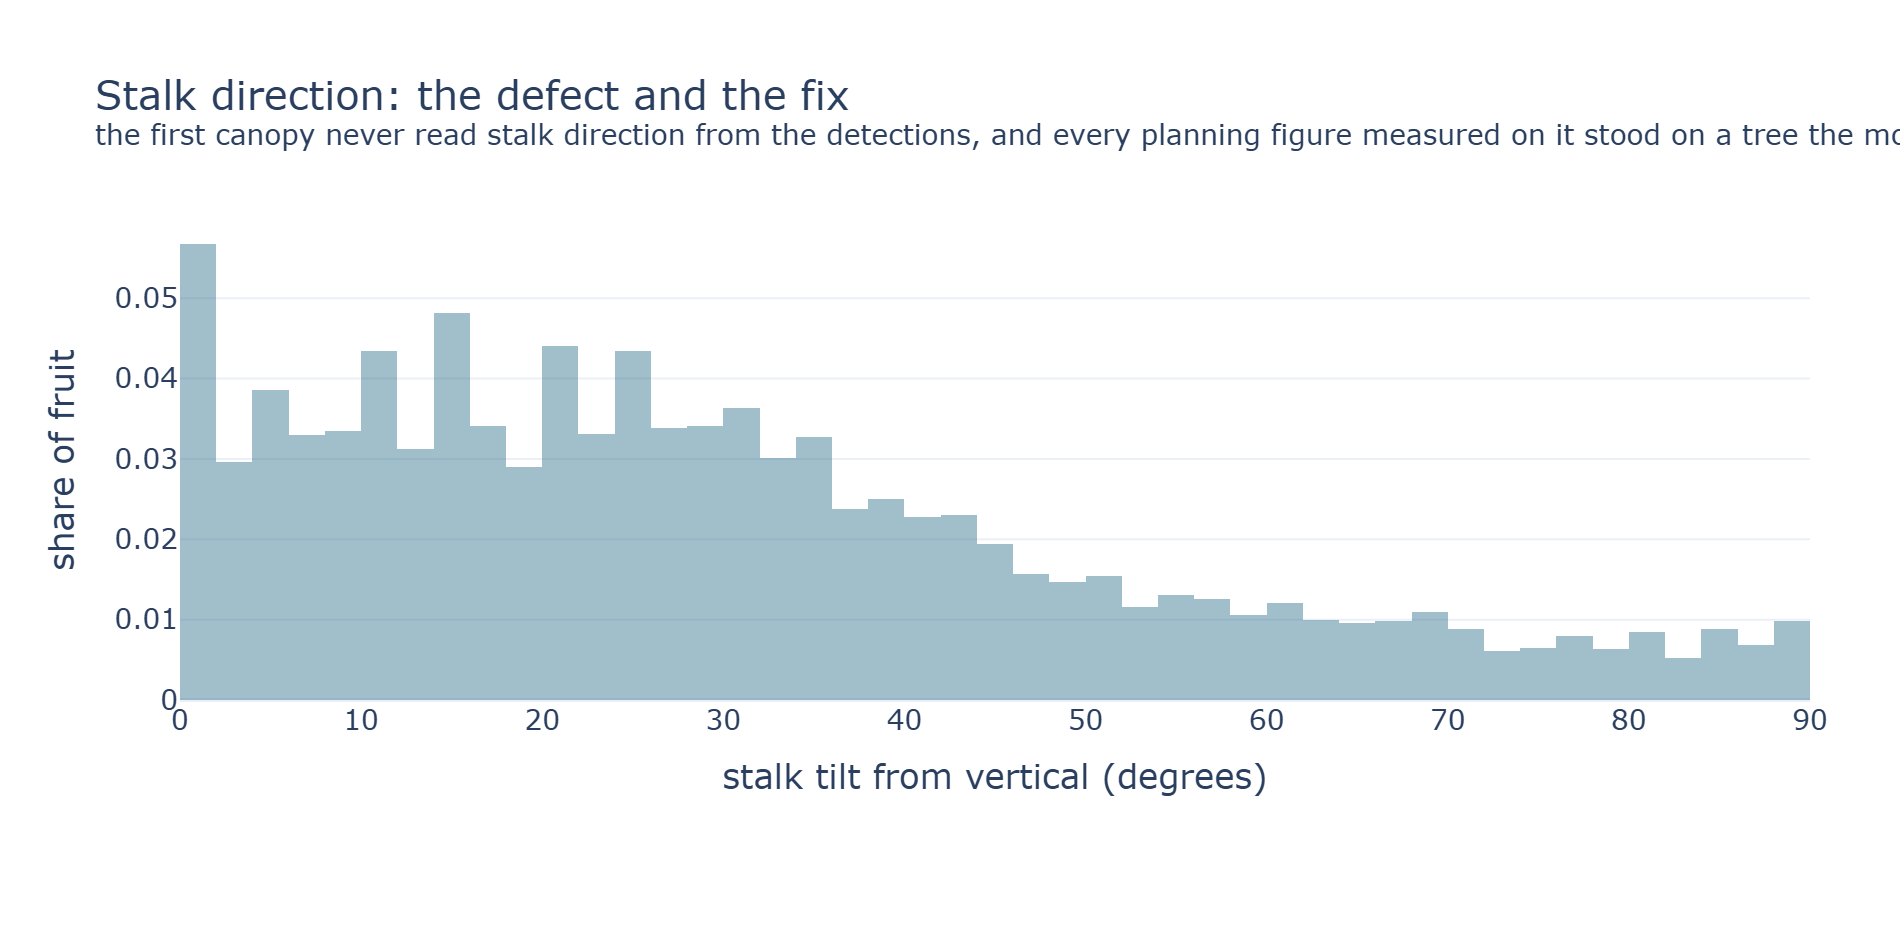

  fig10_canopy_defect.png + .html
  not drawn, missing: trees_uniform_stalk.csv, trees_resampled_stalk.csv


In [7]:
def tilt(df):
    v = df[["sdir_x", "sdir_y", "sdir_z"]].to_numpy(float)
    v = v/np.linalg.norm(v, axis=1, keepdims=True)
    return np.degrees(np.arccos(np.clip(np.abs(v[:, 1]), 0, 1)))


fig = go.Figure()
series, missing = [], []
for label, name, colour in (("first canopy: uniform draw", "trees_uniform_stalk.csv", RED),
                            ("corrected: resampled from detections",
                             "trees_resampled_stalk.csv", GREEN)):
    p = DATA/name
    if p.exists():
        t = tilt(pd.read_csv(p))
        fig.add_trace(go.Histogram(x=t, name=f"{label} — median {np.median(t):.1f}°",
                                   marker_color=colour, opacity=0.55,
                                   histnorm="probability",
                                   xbins=dict(start=0, end=90, size=2)))
    else:
        missing.append(name)

fig.add_trace(go.Histogram(x=tilt_det, name=f"detections — median {np.median(tilt_det):.1f}°",
                           marker_color=BLUE, opacity=0.45, histnorm="probability",
                           xbins=dict(start=0, end=90, size=2)))
fig.update_layout(
    barmode="overlay",
    title="Stalk direction: the defect and the fix"
          "<br><sup>the first canopy never read stalk direction from the detections, and every "
          "planning figure measured on it stood on a tree the model had not seen</sup>",
    xaxis_title="stalk tilt from vertical (degrees)", yaxis_title="share of fruit",
    legend=dict(orientation="h", yanchor="top", y=-0.18,
                    xanchor="center", x=0.5),
    width=950, height=470, **PAPER)
print(" ", save(fig, "fig10_canopy_defect"))
if missing:
    print(f"  not drawn, missing: {', '.join(missing)}")




## 4. Where the fruit go

The single most misread number in this project is "the robot takes half the block". It is true
and it means nothing on its own, because four different denominators sit behind it. This figure
puts them in one place.

**Supports:** *"Of 120 fruit on a tree the robot attempts 62.6 and expects 49.9 with the stem
intact. Only the last step is a decision the farm can change."*


Resorting to unclean kill browser.


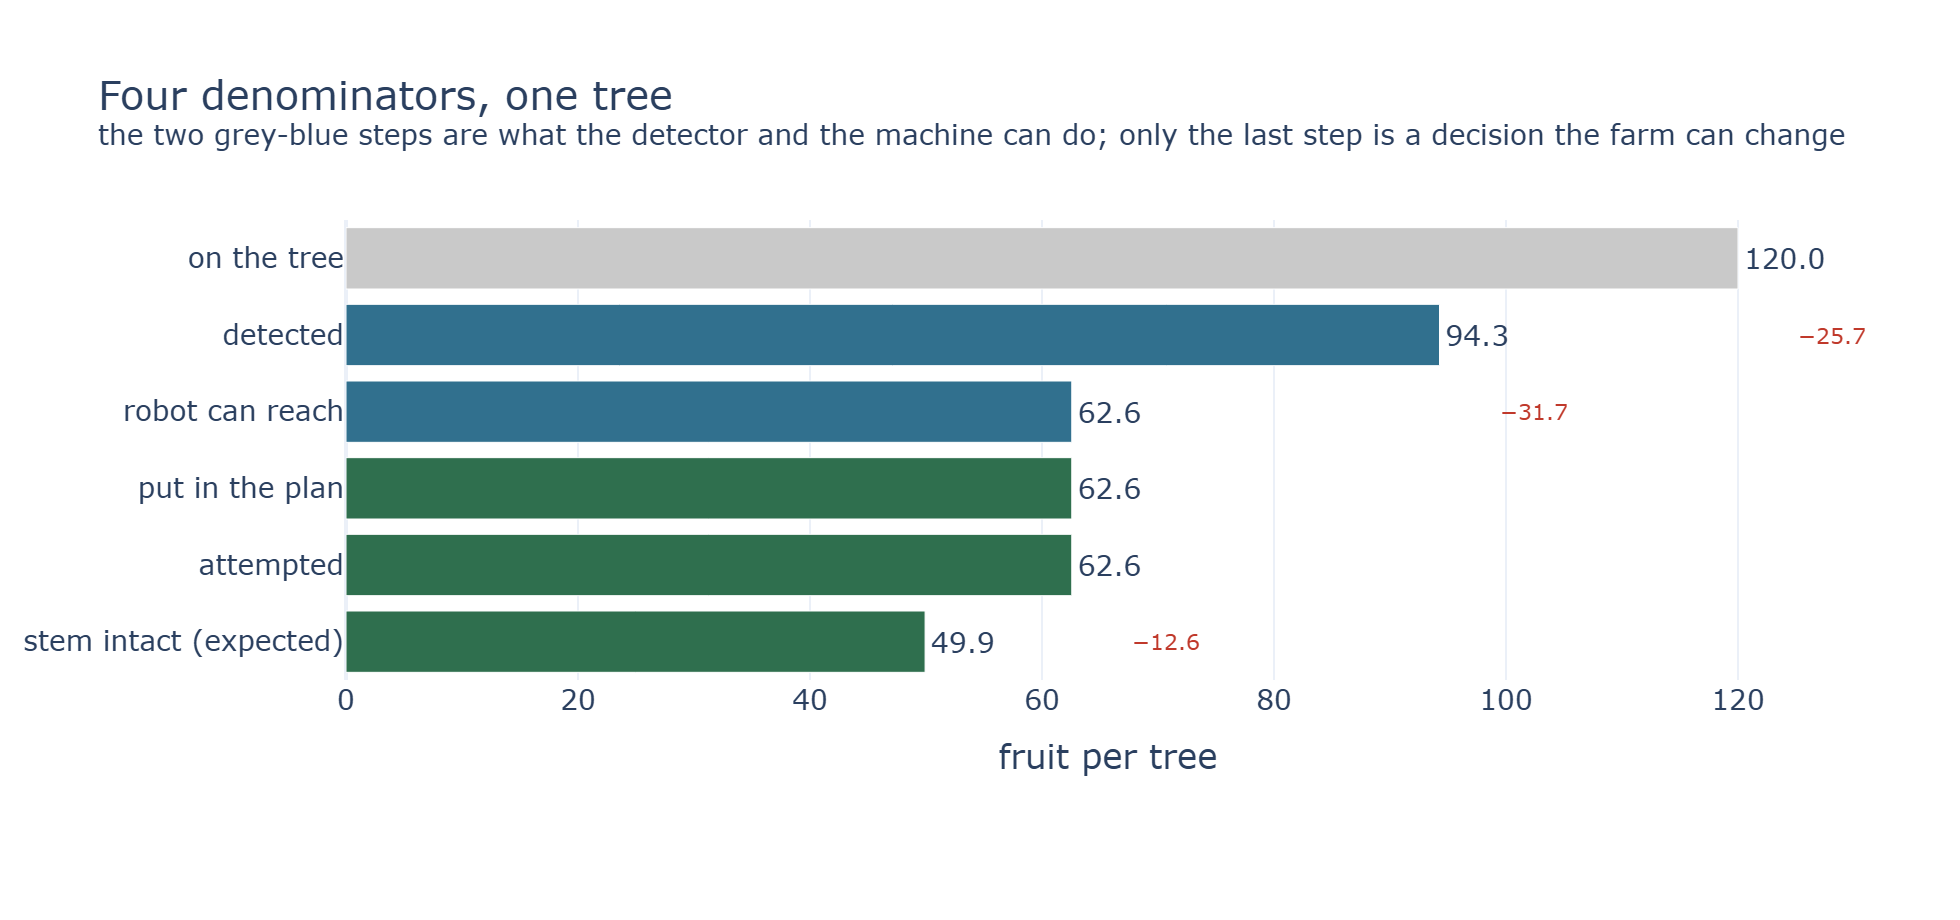

  fig11_denominators.png + .html

  120 on the tree -> 94.3 detected -> 62.6 reachable -> 62.6 attempted -> 49.9 with the stem intact


In [8]:
per_tree = RUNS/"orchard"/"per_tree.csv"
if not per_tree.exists():
    print(f"{per_tree} not found -- run 06_orchard_estimate first")
else:
    T = pd.read_csv(per_tree)
    CH = T[T.config == "chosen"]
    det = E.T[E.T.tree.isin(CH.tree)].groupby("tree").vis_any.sum().mean() \
        if "vis_any" in E.T else np.nan

    steps = [("on the tree", CH.on_tree.mean(), GREY, "everything the canopy carries"),
             ("detected", det, BLUE, "foliage hides the rest"),
             ("robot can reach", CH.robot_reach.mean(), BLUE,
              "base and mast at any position"),
             ("put in the plan", CH.in_plan.mean(), GREEN, "20 stops plus the sweep stage"),
             ("attempted", CH.attempts.mean(), GREEN, "no selection threshold"),
             ("stem intact (expected)", CH.exp_success.mean(), GREEN,
              "what reaches the crate as premium")]

    names = [s[0] for s in steps]
    vals = [s[1] for s in steps]
    fig = go.Figure(go.Bar(
        x=vals, y=names, orientation="h",
        marker_color=[s[2] for s in steps],
        text=[f"{v:.1f}" for v in vals], textposition="outside",
        hovertext=[s[3] for s in steps], hoverinfo="text",
        showlegend=False))

    for i in range(1, len(steps)):
        drop = vals[i-1] - vals[i]
        if drop > 0.5:
            fig.add_annotation(x=vals[i-1], y=names[i], text=f"−{drop:.1f}",
                               showarrow=False, xanchor="left", xshift=28,
                               font=dict(size=11, color=RED))

    fig.update_layout(
        title="Four denominators, one tree"
              "<br><sup>the two grey-blue steps are what the detector and the machine can do; "
              "only the last step is a decision the farm can change</sup>",
        xaxis_title="fruit per tree", yaxis=dict(autorange="reversed"),
        width=980, height=460, **PAPER)
    print(" ", save(fig, "fig11_denominators"))

    print(f"\n  {CH.on_tree.mean():.0f} on the tree -> {det:.1f} detected "
          f"-> {CH.robot_reach.mean():.1f} reachable -> {CH.attempts.mean():.1f} attempted "
          f"-> {CH.exp_success.mean():.1f} with the stem intact")




## 5. What the stop count buys

Three stops maximises premium fruit per hour, which suits a machine skimming an unbounded
orchard. A grower clearing a finite block wants coverage, and the two objectives disagree by
about nine percent on the rate and by a factor of three on the tree.

**Supports:** *"Three stops is the best value for fruit per hour, by nine percent — and it holds
coverage to a third of what the arm can touch."*


Resorting to unclean kill browser.


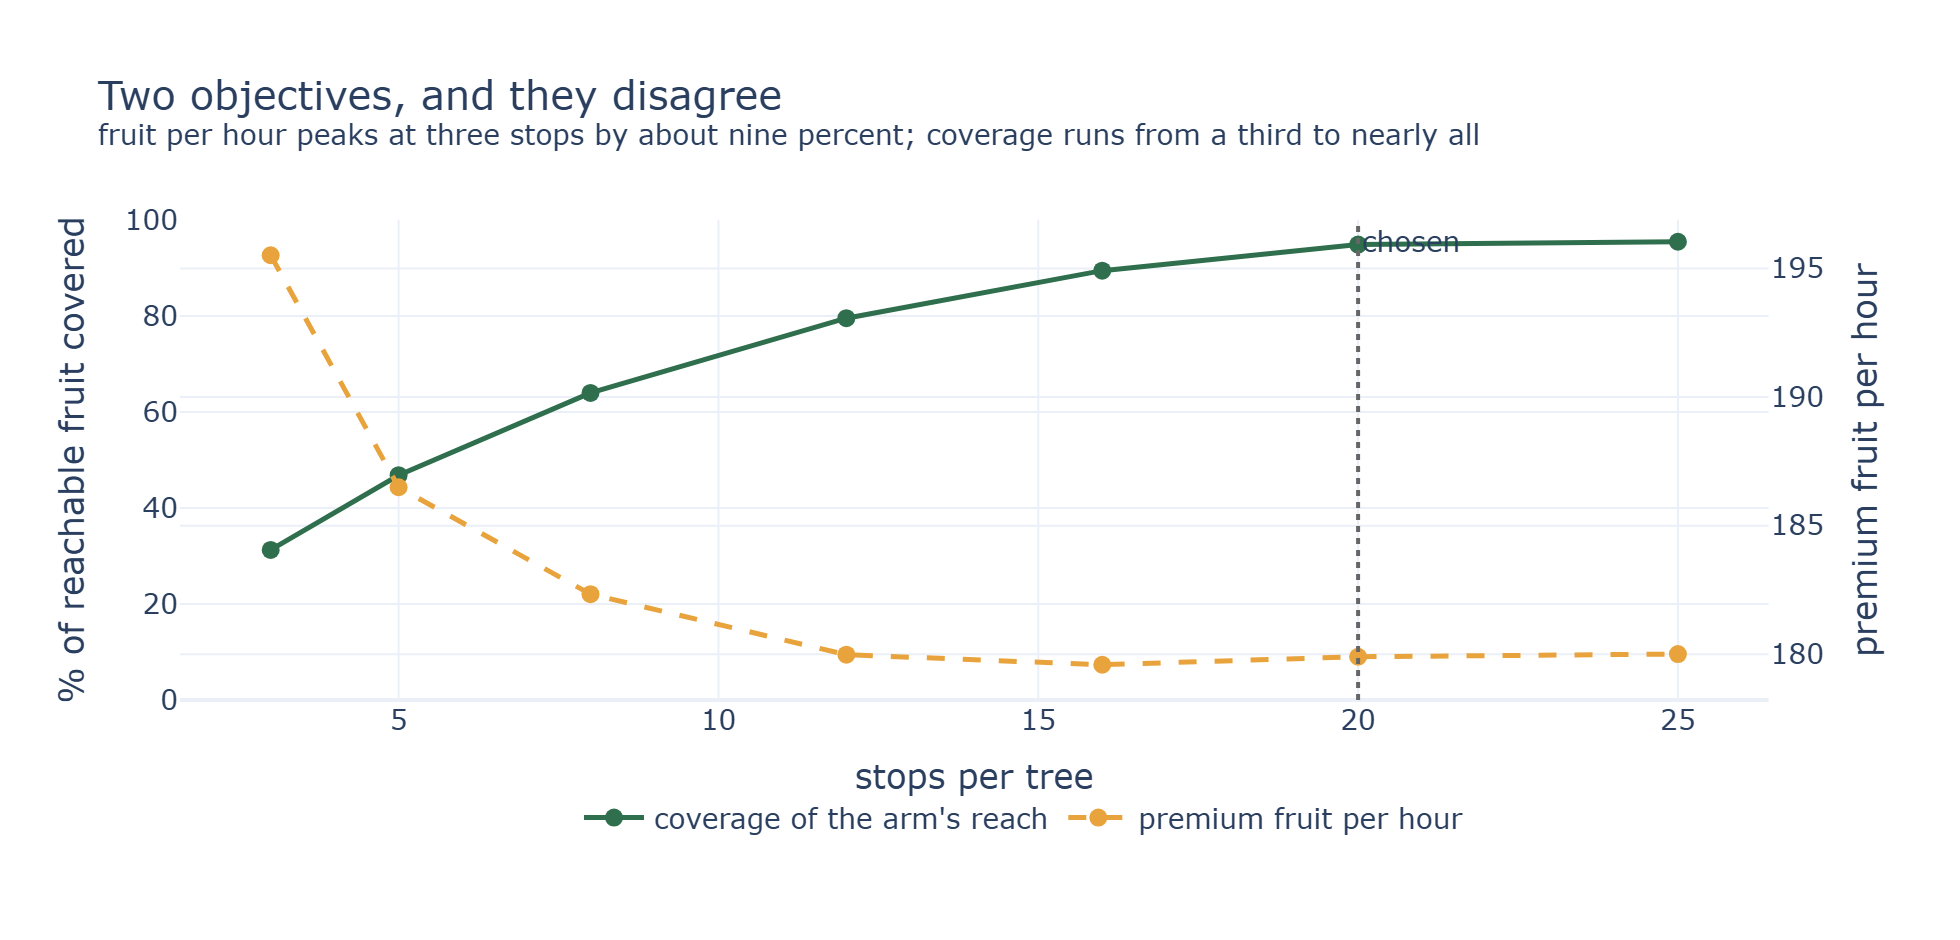

  fig12_stop_count.png + .html

    cover  premium  seconds  per_hour
k                                    
3    31.3     13.8    250.3     195.5
5    46.8     20.0    382.6     186.5
8    64.0     27.1    532.6     182.3
12   79.5     33.0    656.8     180.0
16   89.5     36.1    721.0     179.6
20   94.9     36.6    730.2     179.9
25   95.5     36.8    732.3     180.0


In [9]:
sweep = RUNS/"stations"/"station_sweep.csv"
if not sweep.exists():
    print(f"{sweep} not found -- run 07_station_sweep first")
else:
    S = pd.read_csv(sweep)
    P = S[S["mode"] == "premium"].groupby("k").agg(
        reach=("in_plan", "mean"), premium=("exp_success", "mean"),
        seconds=("seconds", "mean"), robot_reach=("robot_reach", "mean"))
    P["cover"] = P.reach/P.robot_reach*100
    P["per_hour"] = P.premium/(P.seconds + E.TREE_SPACING/E.TRAVEL)*3600

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(go.Scatter(x=P.index, y=P.cover, name="coverage of the arm's reach",
                             mode="lines+markers", line=dict(color=GREEN, width=2.5),
                             marker=dict(size=9)), secondary_y=False)
    fig.add_trace(go.Scatter(x=P.index, y=P.per_hour, name="premium fruit per hour",
                             mode="lines+markers", line=dict(color=AMBER, width=2.5,
                                                             dash="dash"),
                             marker=dict(size=9)), secondary_y=True)
    fig.add_vline(x=20, line=dict(color="#666", dash="dot"),
                  annotation_text="chosen")
    fig.update_xaxes(title_text="stops per tree")
    fig.update_yaxes(title_text="% of reachable fruit covered", secondary_y=False,
                     range=[0, 100])
    fig.update_yaxes(title_text="premium fruit per hour", secondary_y=True)
    fig.update_layout(
        title="Two objectives, and they disagree"
              "<br><sup>fruit per hour peaks at three stops by about nine percent; coverage "
              "runs from a third to nearly all</sup>",
        legend=dict(orientation="h", yanchor="top", y=-0.18,
                    xanchor="center", x=0.5),
        width=980, height=470, **PAPER)
    print(" ", save(fig, "fig12_stop_count"))
    print()
    print(P[["cover", "premium", "seconds", "per_hour"]].round(1).to_string())




## 6. Predicted against realised

Every planning figure rests on the outcome model's probabilities, so the plans were re-run
against the physics itself. The gap is not constant — it depends on which picks the
configuration chooses, and that is a result in its own right.

**Supports:** *"A selection threshold scores the model only where it is confident, which is
where its optimism is largest."*


Resorting to unclean kill browser.


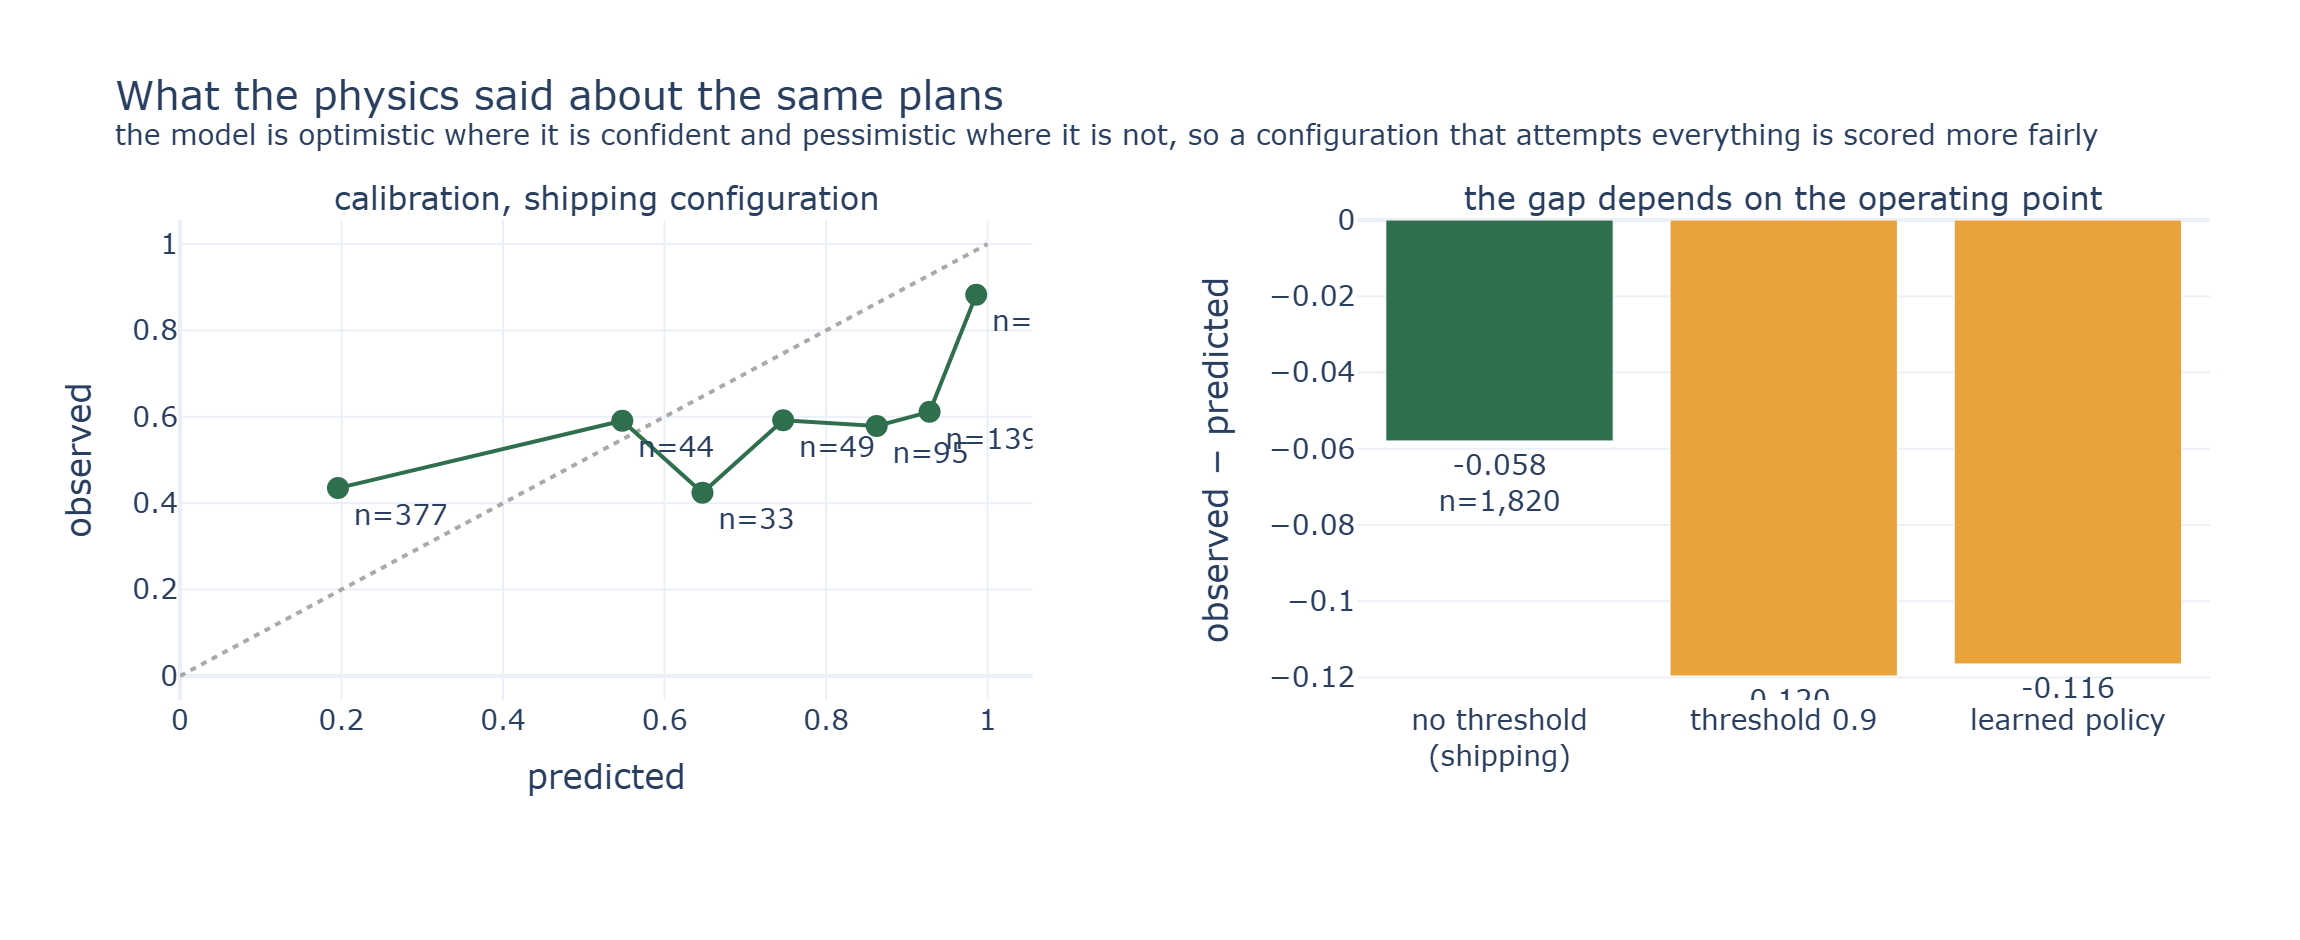

  fig13_fidelity.png + .html

                  n  predicted  observed
bin                                     
(-0.001, 0.5]   377      0.196     0.435
(0.5, 0.6]       44      0.548     0.591
(0.6, 0.7]       33      0.647     0.424
(0.7, 0.8]       49      0.747     0.592
(0.8, 0.9]       95      0.863     0.579
(0.9, 0.95]     139      0.928     0.612
(0.95, 1.0]    1083      0.986     0.883


In [10]:
picks = RUNS/"fidelity"/"validation_picks.csv"
if not picks.exists():
    print(f"{picks} not found -- run 04_fidelity first")
else:
    V = pd.read_csv(picks).drop_duplicates(["tree", "picker", "step"], keep="last")
    V["hit"] = (V.cls == "SUCCESS").astype(int)
    bins = np.array([0, .5, .6, .7, .8, .9, .95, 1.0])

    fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.16,
                        subplot_titles=("calibration, shipping configuration",
                                        "the gap depends on the operating point"))

    SHIP = V[V.picker == "rule"] if (V.picker == "rule").any() else V
    cal = SHIP.assign(bin=pd.cut(SHIP.p_success, bins, include_lowest=True)).groupby(
        "bin", observed=True).agg(n=("hit", "size"), predicted=("p_success", "mean"),
                                  observed=("hit", "mean"))
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", showlegend=False,
                             line=dict(dash="dot", color="#aaa")), row=1, col=1)
    fig.add_trace(go.Scatter(x=cal.predicted, y=cal.observed, mode="markers+lines+text",
                             marker=dict(size=11, color=GREEN), line=dict(color=GREEN),
                             text=[f"n={int(n)}" for n in cal.n],
                             textposition="bottom right", showlegend=False), row=1, col=1)

    order = ["rule", "threshold", "policy"]
    NAME = {"rule": "no threshold<br>(shipping)", "threshold": "threshold 0.9",
            "policy": "learned policy"}
    gaps, labels, ns = [], [], []
    for p in order:
        Q = V[V.picker == p]
        if not len(Q):
            continue
        gaps.append((Q.hit.mean() - Q.p_success.mean()))
        labels.append(NAME[p]); ns.append(len(Q))
    fig.add_trace(go.Bar(x=labels, y=gaps, showlegend=False,
                         marker_color=[GREEN if l.startswith("no") else AMBER
                                       for l in labels],
                         text=[f"{g:+.3f}<br>n={n:,}" for g, n in zip(gaps, ns)],
                         textposition="outside"), row=1, col=2)

    fig.update_xaxes(title_text="predicted", row=1, col=1)
    fig.update_yaxes(title_text="observed", row=1, col=1)
    fig.update_yaxes(title_text="observed − predicted", row=1, col=2)
    fig.update_layout(
        title="What the physics said about the same plans"
              "<br><sup>the model is optimistic where it is confident and pessimistic where it "
              "is not, so a configuration that attempts everything is scored more fairly</sup>",
        width=1150, height=470, **PAPER)
    print(" ", save(fig, "fig13_fidelity"))
    print()
    print(cal.round(3).to_string())




In [11]:
print(f"\nfigures in {REPORT}\n")
for f in sorted(REPORT.glob("*.png")):
    print(f"  {f.name:<36} {f.stat().st_size/1024:8.1f} KB")
missing_png = [f.stem for f in REPORT.glob("*.html")
               if not (REPORT/f"{f.stem}.png").exists()]
if missing_png:
    print(f"\n  html only (needs kaleido): {', '.join(missing_png)}")





figures in c:\aipick\git\runs\report

  fig0_crops.png                          219.6 KB
  fig0_story.png                          243.2 KB
  fig0a_source.png                        163.7 KB
  fig0b_single.png                         23.0 KB
  fig0c_cluster.png                        53.0 KB
  fig0d_tree.png                           77.4 KB
  fig10_canopy_defect.png                 103.8 KB
  fig11_denominators.png                  117.2 KB
  fig12_stop_count.png                    168.9 KB
  fig13_fidelity.png                      195.2 KB
  fig1_scene.png                          145.7 KB
  fig2_plan.png                           432.3 KB
  fig3_predicted_vs_realised.png          135.4 KB
  fig5_layer1_dynamics.png                158.5 KB
  fig6_layer2_cluster.png                 152.2 KB
  fig7_layer3_plan.png                    332.4 KB
  fig8a_diameter.png                       91.0 KB
  fig8b_tilt.png                          117.4 KB
  fig8c_outcomes.png                      1

### Placement

```
fig8   dataset overview        §11.3   what the dataset is
fig9   aperture                §11.3   why the counterfactual structure matters
fig10  canopy defect           §15.1   the defect and the fix
fig11  four denominators       §12.5   where the fruit go
fig12  stop count              §12.4   the two objectives
fig13  fidelity                §12.12  predicted against realised
```

Together with the figures `05_test` produces — the rendered scene, the plan for one tree, the
dynamics and cluster panels — that is nine for a report of this length, which is enough. A
figure that does not carry a sentence should not be in it.
